### Import das Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
pd.set_option('display.max_columns', None)

### Carregando o Dataset

Usaremos um dataset de RH com os seguintes campos:


- id_funcionario
- nome
- idade
- salario
- departamento
- tempo_empresa_anos
- status_constante

In [3]:
df = pd.read_csv("../Data/dataset_data_quality.csv")

df.head()

,id_funcionario,nome,idade,salario,departamento,tempo_empresa_anos,status_constante
0,1,Gabriel,54.0,6083,Marketing,8,ATIVO
1,2,Daniela,33.0,13123,NaN,12,ATIVO
2,3,Helena,57.0,999999,Financeiro,13,ATIVO
3,4,Eduardo,25.0,10123,Operações,9,ATIVO
4,5,Gabriel,NaN,13754,TI,5,ATIVO


In [4]:
df.shape

(1050, 7)

### Visão geral do Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050 entries, 0 to 1049
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_funcionario      1050 non-null   int64  
 1   nome                1050 non-null   object 
 2   idade               978 non-null    float64
 3   salario             1002 non-null   object 
 4   departamento        994 non-null    object 
 5   tempo_empresa_anos  1050 non-null   object 
 6   status_constante    1050 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 57.6+ KB


In [6]:
df.describe(include="all")

,id_funcionario,nome,idade,salario,departamento,tempo_empresa_anos,status_constante
count,1050.000000,1050,978.000000,1002,994,1050,1050
unique,NaN,10,NaN,769,5,23,1
top,NaN,Ana,NaN,999999,Financeiro,16,ATIVO
freq,NaN,124,NaN,46,210,67,1050
mean,502.380952,NaN,43.881391,NaN,NaN,NaN,NaN
std,288.838378,NaN,24.270656,NaN,NaN,NaN,NaN
min,1.000000,NaN,5.000000,NaN,NaN,NaN,NaN
25%,253.250000,NaN,30.000000,NaN,NaN,NaN,NaN
50%,503.500000,NaN,41.000000,NaN,NaN,NaN,NaN
75%,751.750000,NaN,51.000000,NaN,NaN,NaN,NaN


### Criar um resumo simples

In [7]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes,
    "missing_values": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100,
    "unique_values": df.nunique()
})

summary

,column,dtype,missing_values,missing_percent,unique_values
id_funcionario,id_funcionario,int64,0,0.000000,1000
nome,nome,object,0,0.000000,10
idade,idade,float64,72,6.857143,40
salario,salario,object,48,4.571429,769
departamento,departamento,object,56,5.333333,5
tempo_empresa_anos,tempo_empresa_anos,object,0,0.000000,23
status_constante,status_constante,object,0,0.000000,1


### Análise de Missing Values 

In [8]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
})

missing_df

,missing_count,missing_percent
idade,72,6.857143
departamento,56,5.333333
salario,48,4.571429
id_funcionario,0,0.000000
nome,0,0.000000
tempo_empresa_anos,0,0.000000
status_constante,0,0.000000


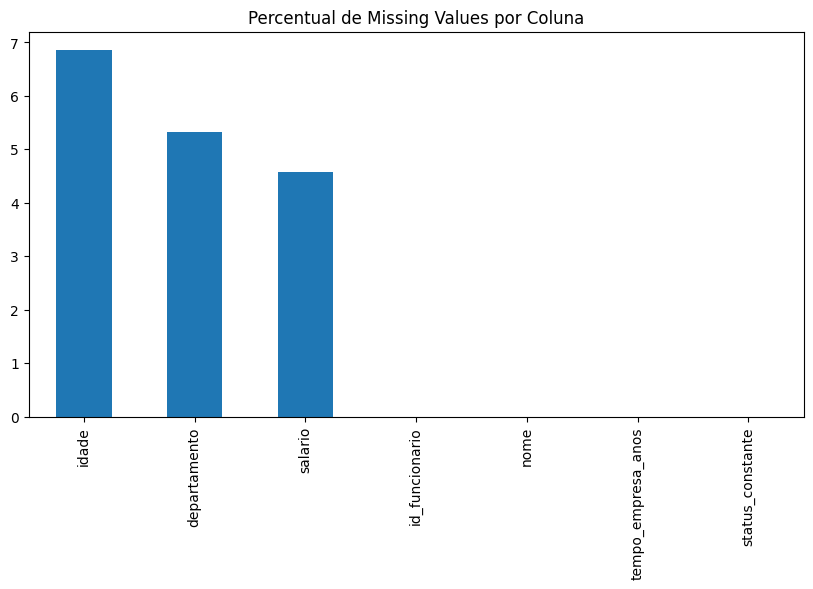

In [9]:
missing_percent.plot(kind="bar", figsize=(10,5))
plt.title("Percentual de Missing Values por Coluna")
plt.show()

### Duplicatas

In [10]:
duplicates = df.duplicated().sum()

duplicates

np.int64(50)

In [11]:
duplicates_percent = duplicates / len(df) * 100

duplicates_percent

np.float64(4.761904761904762)

### Colunas Constantes

In [12]:
cardinality = df.nunique().sort_values(ascending=False)

cardinality

id_funcionario        1000
salario                769
idade                   40
tempo_empresa_anos      23
nome                    10
departamento             5
status_constante         1
dtype: int64

### Alerta para colunas com alta Cardinalidade

In [13]:
high_cardinality = cardinality[cardinality > len(df)*0.9]

high_cardinality

id_funcionario    1000
dtype: int64

### Detecção de Outliers

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns

In [15]:
def detect_outliers(column):
    
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return ((column < lower) | (column > upper)).sum()

In [16]:
outliers = {}

for col in numeric_cols:
    outliers[col] = detect_outliers(df[col])

outliers

{'id_funcionario': np.int64(0), 'idade': np.int64(53)}

### Correlação

In [17]:
corr_matrix = df[numeric_cols].corr()

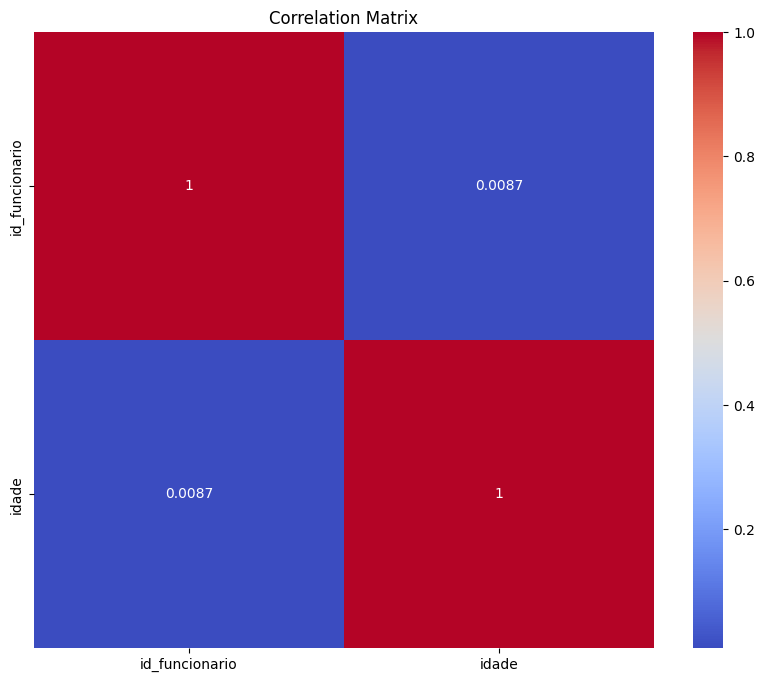

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Data Health Score

In [19]:
score = 100

In [20]:
if missing_percent.max() > 20:
    score -= 10

In [21]:
if duplicates_percent > 5:
    score -= 10

In [22]:
# Colunas constantes
constant_columns = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]

print("Colunas constantes:", constant_columns)
print("Quantidade:", len(constant_columns))

Colunas constantes: ['status_constante']
Quantidade: 1


In [23]:
for col, value in outliers.items():
    if value > len(df) * 0.1:
        score -= 5

In [24]:
score

100

### Classificação

In [25]:
def classify_dataset(score):
    
    if score >= 90:
        return "Excelente"
    
    elif score >= 75:
        return "Boa"
    
    elif score >= 50:
        return "Regular"
    
    else:
        return "Crítica"

In [26]:
classify_dataset(score)

'Excelente'